### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


In [2]:
import matplotlib.pyplot as plt

#1. Análisis de facturación



In [3]:
def suma_x_tienda(td):
  return td['Precio'].sum()

sum_t1 = suma_x_tienda(tienda)
sum_t2 = suma_x_tienda(tienda2)
sum_t3 = suma_x_tienda(tienda3)
sum_t4 = suma_x_tienda(tienda4)

print('Total de Ventas en la tienda 1: ', int(sum_t1))
print('Total de Ventas en la tienda 2: ', int(sum_t2))
print('Total de Ventas en la tienda 3: ', int(sum_t3))
print('Total de Ventas en la tienda 4: ', int(sum_t4))

Total de Ventas en la tienda 1:  1150880400
Total de Ventas en la tienda 2:  1116343500
Total de Ventas en la tienda 3:  1098019600
Total de Ventas en la tienda 4:  1038375700


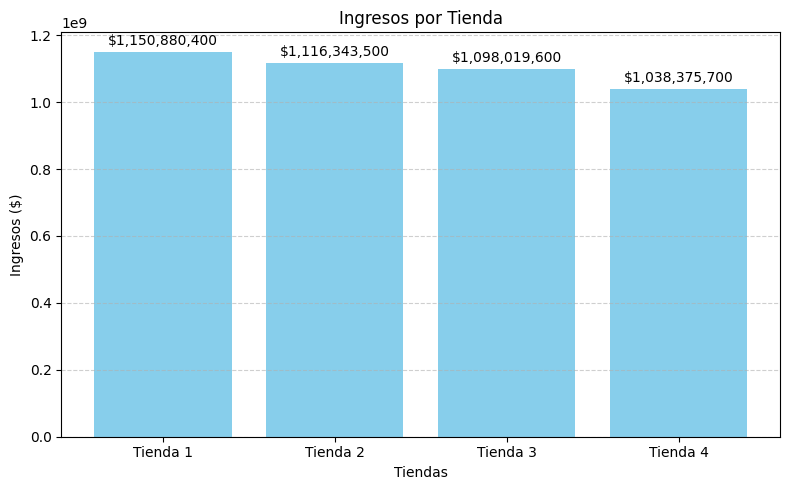

In [4]:
# Datos de las tiendas
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ingresos_por_tienda = [sum_t1, sum_t2, sum_t3, sum_t4]

# Crear figura del gráfico
plt.figure(figsize=(8, 5))
barras = plt.bar(nombres_tiendas, ingresos_por_tienda, color='#87CEEB')

# Agregar título y etiquetas
plt.title('Ingresos por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Ingresos ($)')

# Cuadrícula en el eje Y
plt.grid(True, axis='y', linestyle='--', alpha=0.6)

# Mostrar el ingreso sobre cada barra
for indice, ingreso in enumerate(ingresos_por_tienda):
    posicion_x = indice
    posicion_y = ingreso + max(ingresos_por_tienda) * 0.01
    texto = f"${int(ingreso):,}"

    plt.text(posicion_x, posicion_y, texto, ha='center', va='bottom', fontsize=10)

#  Mostrar gráfico completo
plt.tight_layout()
plt.show()



# 2. Ventas por categoría

In [5]:
# función para contar las categorias mas comunes en un dataFrame
def contar_categorias(df, top_n=5):
  conteo = df['Categoria del Producto'].value_counts().head(top_n)
  print("Top", top_n , "Categoria más vendidas:")
  print(conteo)
  return conteo

# Función para obtener la lista de categorías únicas de una tienda
def listar_categorias(df):
  categorias = df['Categoría del Producto'].dropna().unique().tolist()
  print("Lista de categorías:")
  print(categorias)
  return categorias

# Lista de tiendas (DataFrame)
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Recorrer cada tienda y mostrar sus categorías
for i, tienda_df in enumerate(tiendas, start=1):
  print(f"\nAnálisis de la tienda {i}:")
  listar_categorias(tienda_df)


Análisis de la tienda 1:
Lista de categorías:
['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos', 'Artículos para el hogar', 'Deportes y diversión', 'Libros', 'Instrumentos musicales']

Análisis de la tienda 2:
Lista de categorías:
['Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Artículos para el hogar', 'Juguetes', 'Electrodomésticos', 'Libros']

Análisis de la tienda 3:
Lista de categorías:
['Electrodomésticos', 'Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Juguetes', 'Artículos para el hogar', 'Libros']

Análisis de la tienda 4:
Lista de categorías:
['Electrodomésticos', 'Muebles', 'Deportes y diversión', 'Libros', 'Electrónicos', 'Instrumentos musicales', 'Juguetes', 'Artículos para el hogar']


In [6]:
# Función para obtener categorías únicas
def obtener_categorias_unicas(df):
    return df['Categoría del Producto'].dropna().unique().tolist()

# Función para contar productos por categoría
def contar_productos_por_categoria(df):
    return df['Categoría del Producto'].value_counts().to_dict()

# Lista de tiendas y nombres
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Recorrer cada tienda
for nombre, df in zip(nombres, tiendas):
    print(f"\n Análisis de {nombre}:")

    categorias = obtener_categorias_unicas(df)
    print("Categorías únicas:", categorias)

    conteo = contar_productos_por_categoria(df)
    print("Cantidad por categoría:", conteo)



 Análisis de Tienda 1:
Categorías únicas: ['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos', 'Artículos para el hogar', 'Deportes y diversión', 'Libros', 'Instrumentos musicales']
Cantidad por categoría: {'Muebles': 465, 'Electrónicos': 448, 'Juguetes': 324, 'Electrodomésticos': 312, 'Deportes y diversión': 284, 'Instrumentos musicales': 182, 'Libros': 173, 'Artículos para el hogar': 171}

 Análisis de Tienda 2:
Categorías únicas: ['Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Artículos para el hogar', 'Juguetes', 'Electrodomésticos', 'Libros']
Cantidad por categoría: {'Muebles': 442, 'Electrónicos': 422, 'Juguetes': 313, 'Electrodomésticos': 305, 'Deportes y diversión': 275, 'Instrumentos musicales': 224, 'Libros': 197, 'Artículos para el hogar': 181}

 Análisis de Tienda 3:
Categorías únicas: ['Electrodomésticos', 'Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Juguetes', 'Artículos para el hogar', 'Libros']
Can

In [7]:
def categorias_tiendas(td):
    return list(td['Categoría del Producto'].unique())

categorias_T1 = categorias_tiendas(tienda)
categorias_T2 = categorias_tiendas(tienda2)
categorias_T3 = categorias_tiendas(tienda3)
categorias_T4 = categorias_tiendas(tienda4)

print(categorias_T1)
print(categorias_T2)
print(categorias_T3)
print(categorias_T4)

def cantidad_x_categorias(tienda):
    return tienda['Categoría del Producto'].value_counts().to_dict()

cant_t1 = cantidad_x_categorias(tienda)
cant_t2 = cantidad_x_categorias(tienda2)
cant_t3 = cantidad_x_categorias(tienda3)
cant_t4 = cantidad_x_categorias(tienda4)

print(cant_t1)
print(cant_t2)
print(cant_t3)
print(cant_t4)

['Electrónicos', 'Muebles', 'Juguetes', 'Electrodomésticos', 'Artículos para el hogar', 'Deportes y diversión', 'Libros', 'Instrumentos musicales']
['Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Artículos para el hogar', 'Juguetes', 'Electrodomésticos', 'Libros']
['Electrodomésticos', 'Muebles', 'Instrumentos musicales', 'Deportes y diversión', 'Electrónicos', 'Juguetes', 'Artículos para el hogar', 'Libros']
['Electrodomésticos', 'Muebles', 'Deportes y diversión', 'Libros', 'Electrónicos', 'Instrumentos musicales', 'Juguetes', 'Artículos para el hogar']
{'Muebles': 465, 'Electrónicos': 448, 'Juguetes': 324, 'Electrodomésticos': 312, 'Deportes y diversión': 284, 'Instrumentos musicales': 182, 'Libros': 173, 'Artículos para el hogar': 171}
{'Muebles': 442, 'Electrónicos': 422, 'Juguetes': 313, 'Electrodomésticos': 305, 'Deportes y diversión': 275, 'Instrumentos musicales': 224, 'Libros': 197, 'Artículos para el hogar': 181}
{'Muebles': 499, 'Electrónicos':

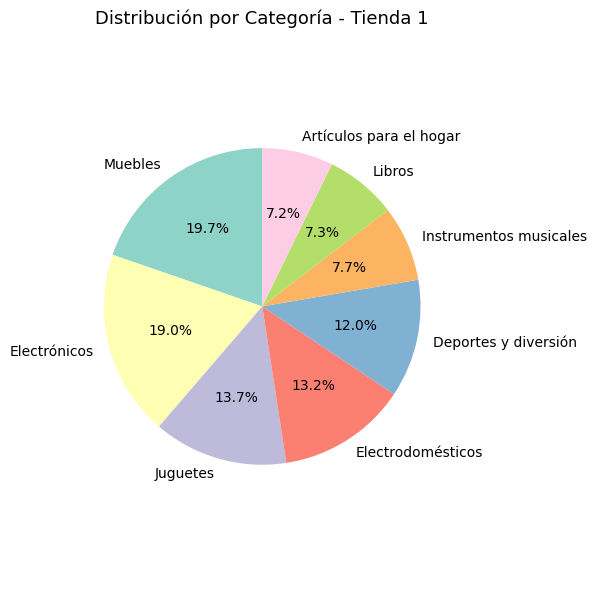

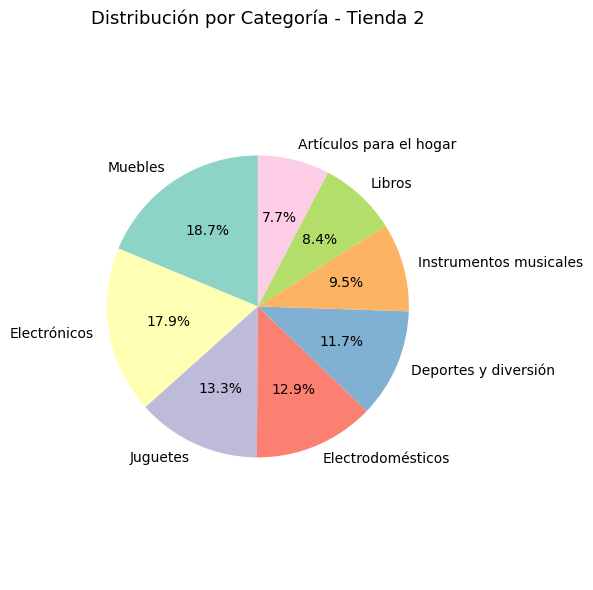

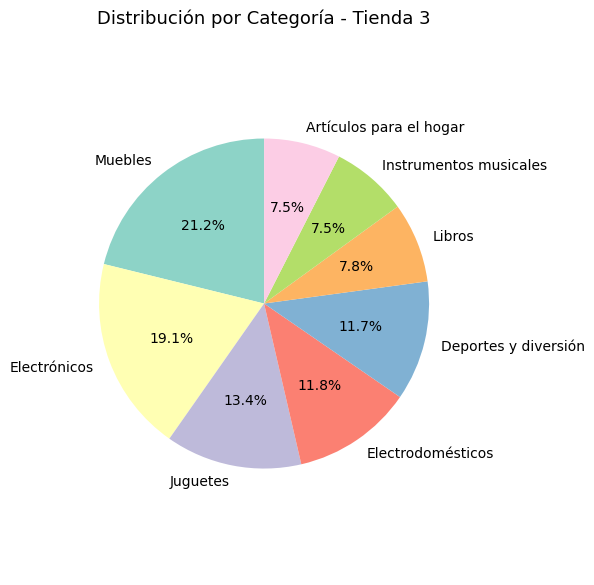

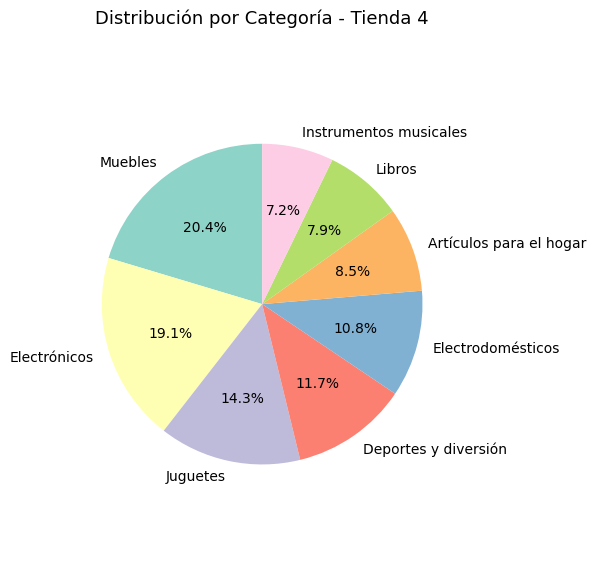

In [8]:
# Lista de diccionarios con los conteos por categoría por tienda
conteos_por_tienda = [
    tienda['Categoría del Producto'].value_counts().to_dict()
    for tienda in [tienda, tienda2, tienda3, tienda4]
]

# Nombres para las tiendas
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Generar un gráfico circular para cada tienda
for nombre, conteo in zip(nombres_tiendas, conteos_por_tienda):
    plt.figure(figsize=(6, 6))  # Crear nueva figura de tamaño 6x6
    plt.pie(
        conteo.values(),             # Valores de los productos por categoría
        labels=conteo.keys(),        # Etiquetas (nombres de categorías)
        autopct='%1.1f%%',           # Mostrar porcentaje con 1 decimal
        startangle=90,               # Iniciar desde arriba
        colors=plt.cm.Set3.colors    # Paleta de colores agradable
    )
    plt.title(f'Distribución por Categoría - {nombre}', fontsize=13)
    plt.axis('equal')  # Mantiene proporciones de círculo
    plt.tight_layout()  # Ajusta el gráfico automáticamente
    plt.show()  # Mostrar gráfico


# 3. Calificación promedio de la tienda


In [9]:
# Lista de DataFrames y nombres para impresión
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Mostrar cuántos valores nulos hay en la columna 'Calificación' por tienda
for nombre, df in zip(nombres, tiendas):
    nulos = df['Calificación'].isnull().sum()
    print(f"{nombre} - valores nulos en la columna 'Calificación': {nulos}")


Tienda 1 - valores nulos en la columna 'Calificación': 0
Tienda 2 - valores nulos en la columna 'Calificación': 0
Tienda 3 - valores nulos en la columna 'Calificación': 0
Tienda 4 - valores nulos en la columna 'Calificación': 0


In [10]:
# Función para obtener el promedio de calificación
def obtener_calificacion_promedio(df):
  return df['Calificación'].mean()

# lista de DataFrames y sus nombres
tiendas = [tienda, tienda2, tienda3, tienda4]
nombres = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Calcular y mostrar el promedio de calificación por tienda
for nombre, tienda_df in zip(nombres_tiendas, tiendas):
  promedio = obtener_calificacion_promedio(tienda_df)
  print(f"{nombre} - Promedio de Calificación: {promedio:.2f}")

Tienda 1 - Promedio de Calificación: 3.98
Tienda 2 - Promedio de Calificación: 4.04
Tienda 3 - Promedio de Calificación: 4.05
Tienda 4 - Promedio de Calificación: 4.00


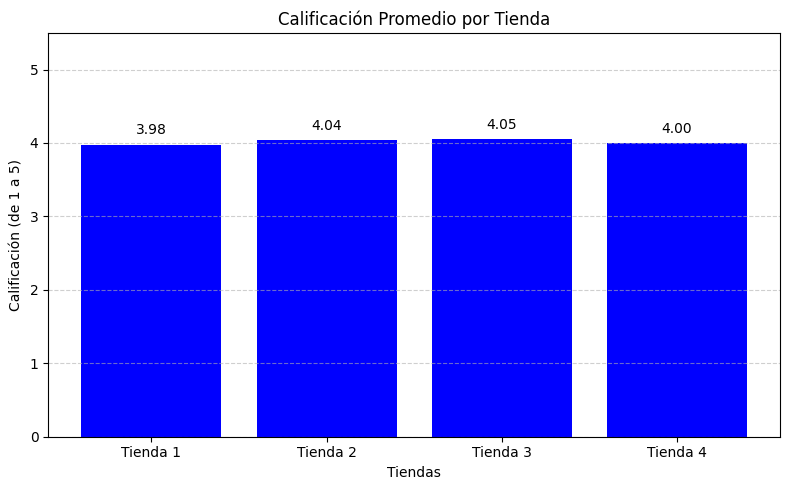

In [11]:
# Definimos la función para calcular calificación promedio
def calificacion_promedio(tienda):
    return tienda['Calificación'].mean()

# Calculamos las calificaciones promedio por tienda
calif_t1 = calificacion_promedio(tienda)
calif_t2 = calificacion_promedio(tienda2)
calif_t3 = calificacion_promedio(tienda3)
calif_t4 = calificacion_promedio(tienda4)

# Lista de valores y nombres
calificaciones = [calif_t1, calif_t2, calif_t3, calif_t4]
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Creamos la figura del gráfico
plt.figure(figsize=(8, 5))
barras = plt.bar(nombres_tiendas, calificaciones, color='blue')

# Agregamos etiquetas sobre cada barra
for i, barra in enumerate(barras):
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.1,
        f'{calificaciones[i]:.2f}',
        ha='center', va='bottom', fontsize=10
    )

# Título y etiquetas
plt.title('Calificación Promedio por Tienda')
plt.xlabel('Tiendas')
plt.ylabel('Calificación (de 1 a 5)')
plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 4. Productos más y menos vendidos

In [12]:
def productos_mas_y_menos_vendidos(tienda):
    """
    Devuelve los 5 productos más vendidos y los 5 menos vendidos
    a partir de una columna 'Producto' de un DataFrame.
    """
    # Eliminar valores nulos por seguridad
    productos = tienda['Producto'].dropna()

    # Contar cuántas veces se vendió cada producto
    conteo = productos.value_counts()

    # Obtener los 5 más vendidos
    top_5 = conteo.head(5)

    # Obtener los 5 menos vendidos
    bottom_5 = conteo.tail(5)

    return top_5, bottom_5


In [13]:
# Obtener productos más y menos vendidos por tienda
productos_top_t1, productos_bottom_t1 = productos_mas_y_menos_vendidos(tienda)
productos_top_t2, productos_bottom_t2 = productos_mas_y_menos_vendidos(tienda2)
productos_top_t3, productos_bottom_t3 = productos_mas_y_menos_vendidos(tienda3)
productos_top_t4, productos_bottom_t4 = productos_mas_y_menos_vendidos(tienda4)

# Mostrar resultados por tienda
print("Tienda 1 - Productos más vendidos:")
print(productos_top_t1)
print("\nTienda 1 - Productos menos vendidos:")
print(productos_bottom_t1)

print("\nTienda 2 - Productos más vendidos:")
print(productos_top_t2)
print("\nTienda 2 - Productos menos vendidos:")
print(productos_bottom_t2)

print("\nTienda 3 - Productos más vendidos:")
print(productos_top_t3)
print("\nTienda 3 - Productos menos vendidos:")
print(productos_bottom_t3)

print("\nTienda 4 - Productos más vendidos:")
print(productos_top_t4)
print("\nTienda 4 - Productos menos vendidos:")
print(productos_bottom_t4)


Tienda 1 - Productos más vendidos:
Producto
Microondas          60
TV LED UHD 4K       60
Armario             60
Secadora de ropa    58
Mesa de noche       56
Name: count, dtype: int64

Tienda 1 - Productos menos vendidos:
Producto
Ciencia de datos con Python    39
Pandereta                      36
Olla de presión                35
Auriculares con micrófono      33
Celular ABXY                   33
Name: count, dtype: int64

Tienda 2 - Productos más vendidos:
Producto
Iniciando en programación    65
Microondas                   62
Batería                      61
Guitarra acústica            58
Pandereta                    58
Name: count, dtype: int64

Tienda 2 - Productos menos vendidos:
Producto
Auriculares        37
Sillón             35
Mesa de comedor    34
Impresora          34
Juego de mesa      32
Name: count, dtype: int64

Tienda 3 - Productos más vendidos:
Producto
Kit de bancas      57
Mesa de comedor    56
Cama king          56
Set de ollas       55
Mesa de noche      55
Nam

In [14]:
def resumen_productos_mas_y_menos_vendidos(productos_top, productos_bottom, tienda_nombre):
    if isinstance(productos_top, pd.Series):
        productos_top = productos_top.items()
    if isinstance(productos_bottom, pd.Series):
        productos_bottom = productos_bottom.items()

    # Verificación de que exista al menos un proucto
    if not productos_top or not productos_bottom:
        print(f"Error: No hay productos disponibles en Tienda {tienda_nombre}")
        return

    try:

        prod_max, cant_max = list(productos_top)[0]
        prod_min, cant_min = list(productos_bottom)[-1]

        print(f"Resumen Tienda {tienda_nombre}:")
        print(f"- Producto más vendido: {prod_max} con {cant_max} unidades")
        print(f"- Producto menos vendido: {prod_min} con {cant_min} unidades\n")

    except Exception as e:
        print(f"Error al procesar Tienda {tienda_nombre}: {e}")

# Resumen de cada tienda
resumen_productos_mas_y_menos_vendidos(productos_top_t1, productos_bottom_t1, '1')
resumen_productos_mas_y_menos_vendidos(productos_top_t2, productos_bottom_t2, '2')
resumen_productos_mas_y_menos_vendidos(productos_top_t3, productos_bottom_t3, '3')
resumen_productos_mas_y_menos_vendidos(productos_top_t4, productos_bottom_t4, '4')

Resumen Tienda 1:
- Producto más vendido: Microondas con 60 unidades
- Producto menos vendido: Celular ABXY con 33 unidades

Resumen Tienda 2:
- Producto más vendido: Iniciando en programación con 65 unidades
- Producto menos vendido: Juego de mesa con 32 unidades

Resumen Tienda 3:
- Producto más vendido: Kit de bancas con 57 unidades
- Producto menos vendido: Bloques de construcción con 35 unidades

Resumen Tienda 4:
- Producto más vendido: Cama box con 62 unidades
- Producto menos vendido: Guitarra eléctrica con 33 unidades



# 5. Envío promedio por tienda

In [15]:
def promedio_costo_envio(df):
  """Devuelve el promedio del costo de envio de cada tienda"""
  return df['Costo de envío'].mean()

# Lista de tiendas
tiendas = [tienda, tienda2, tienda3, tienda4]

#Calcular y mostrar promedios de manera dinámica
for i, t in enumerate(tiendas, start=1):
  promedio = promedio_costo_envio(t)
  print(f'Promedio costo de envío tienda {i}: {promedio:.2f}')


Promedio costo de envío tienda 1: 26018.61
Promedio costo de envío tienda 2: 25216.24
Promedio costo de envío tienda 3: 24805.68
Promedio costo de envío tienda 4: 23459.46


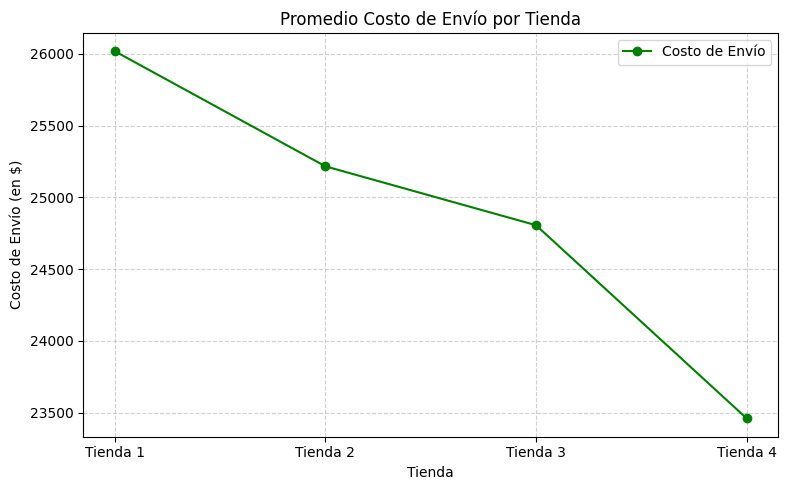

In [17]:
# Función para calcular promedio de costo de envío
def promedio_costo_envio(tienda):
    return tienda['Costo de envío'].mean()

# Calcular promedio para cada tienda
promedio_t1 = promedio_costo_envio(tienda)
promedio_t2 = promedio_costo_envio(tienda2)
promedio_t3 = promedio_costo_envio(tienda3)
promedio_t4 = promedio_costo_envio(tienda4)

# Nombres de las tiendas
nombres_tiendas = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']

# Lista de promedios (ahora con los nombres correctos)
promedios_costo_envio = [promedio_t1, promedio_t2, promedio_t3, promedio_t4]

# Gráfico de líneas
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(
    nombres_tiendas,
    promedios_costo_envio,
    marker='o',
    color='green',
    linestyle='-',
    label='Costo de Envío'
)

plt.title('Promedio Costo de Envío por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo de Envío (en $)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Propósito del análisis
El análisis fue realizado a partir de un reto propuesto por el equipo de Alaura Latam, centrado en examinar una estructura de datos específica del Sr. Juan, un comerciante y emprendedor. El objetivo del reto era aplicar los conocimientos adquiridos en la introducción a Python, dentro del curso de Data Science que estoy cursando actualmente, utilizando herramientas tecnológicas para facilitar la manipulación y comprensión de datos.

El reto consistía en reorganizar y analizar los datos desde cinco enfoques principales:

Ingresos totales de las tiendas.

Categorías de productos más y menos vendidas.

Calificaciones promedio de los clientes por tienda.

Productos más y menos vendidos.

Costo de envío promedio por tienda.

La información proporcionada y el análisis realizado permitieron identificar el comportamiento y rendimiento de cada tienda a lo largo del tiempo, lo que facilitó generar recomendaciones claras y fundamentadas.

Análisis de ingresos totales
En cuanto a la facturación, se identificó que la tienda 1 fue la que obtuvo mayores ingresos durante el periodo analizado. Al ser la primera tienda establecida por el Sr. Juan, se asume que fue el inicio de su emprendimiento, por lo que no resulta sorprendente que sea la más consolidada y rentable.

Se observa una tendencia decreciente en la facturación conforme avanzamos de la tienda 1 a la tienda 4, siendo esta última la que menos ingresos genera, con una diferencia de $112,504,700 respecto a la tienda 1. Aunque la tienda 1 lidera en ventas, este análisis no toma en cuenta factores como la ubicación geográfica o el número de clientes por tienda, que podrían influir en estos resultados.

Ventas por categoría / Productos más y menos vendidos
En este apartado, se observa que todas las tiendas manejan las mismas categorías de productos:

Muebles

Electrodomésticos

Juguetes

Electrónicos

Instrumentos musicales

Libros

Deportes y diversión

Artículos para el hogar

Cada tienda presenta distintos porcentajes de venta por categoría, pero de forma general, las categorías de Muebles y Electrónicos son las más vendidas. La tienda 4, que es la que menos factura, también presenta el menor porcentaje de ventas en la mayoría de categorías, aunque destaca en la categoría de Juguetes, lo que podría indicar una especialización en este rubro además de los muebles y electrónicos.

Calificación promedio por tienda
La calificación promedio de cada tienda es un dato esencial para medir la satisfacción del cliente y evaluar posibles áreas de mejora en el servicio. En este análisis, las calificaciones son bastante similares entre las tiendas, rondando el valor de 4 sobre 5.

Llama la atención que la tienda 1, pese a ser la de mayor facturación, es la que presenta la calificación más baja. Esto podría deberse a la alta demanda y volumen de operaciones, lo que sugiere la necesidad de reforzar las buenas prácticas de atención al cliente y mejorar los tiempos de respuesta para optimizar tanto el servicio como las ventas.

Orden de tiendas según calificación, de mayor a menor:

Tienda 3

Tienda 2

Tienda 4

Tienda 1

Productos más y menos vendidos
Aunque las tiendas venden los mismos productos, se detectan diferencias leves en la rotación de cada uno. No se identificó una tendencia clara hacia un producto específico en todo el conjunto de tiendas, pero sí se puede afirmar que los productos más vendidos en las tiendas 1 y 3 son principalmente Electrónicos y Muebles.

Costo de envío promedio
Al analizar el costo promedio de envío, se confirma que la tienda 1, al ser la de mayor facturación, también incurre en mayores gastos de envío. Por el contrario, la tienda 4 tiene los menores costos en este aspecto.

No obstante, se observa que, a pesar de su baja facturación, la tienda 4 mantiene un buen volumen de ventas en categorías de alto valor como electrónicos y muebles. Esto sugiere que podrían estarse aplicando buenas prácticas logísticas en esta tienda que valdría la pena replicar en las demás.

Conclusión
Considerando todos los puntos analizados y yendo más allá de los datos entregados, es posible que la baja facturación en las tiendas 2, 3 y 4 esté relacionada con factores geográficos, de liderazgo o gestión. Los ingresos, ganancias, ventas y satisfacción del cliente son claves para obtener una visión clara del rendimiento del negocio y tomar decisiones acertadas.

Dado que el objetivo del ejercicio es brindar una recomendación de venta al Sr. Juan, desde mi análisis le sugeriría considerar la venta de la tienda 4, debido a su bajo nivel de ventas y a la posibilidad de que sea la tienda más reciente. No obstante, resaltaría que esta tienda presenta buenas prácticas en términos de atención al cliente y eficiencia logística, por lo que sería valioso trasladar esos aprendizajes a las otras tiendas antes de tomar una decisión definitiva.

Desde otra perspectiva, una opción viable sería realizar una reestructuración general en las cuatro tiendas, llevando a cabo auditorías internas para identificar oportunidades de mejora específicas. Esto podría revelar problemas de gestión o de estrategia que estén afectando el rendimiento de algunas tiendas, permitiendo corregirlos sin necesidad de cerrar o vender alguna de ellas.

Como encargado del análisis, considero que esta última alternativa podría ser más beneficiosa a largo plazo, aunque entiendo que el Sr. Juan puede tener razones adicionales para considerar la venta de una tienda.